Brute-forcing the integral

$S_{\ell}(k_1, k_2) = \int dk k^2 P(k) \int d\chi W(\chi) k_1 j_{\ell}(k \chi) j_{\ell}(k_1 \chi) \int d\chi W(\chi) k_2 j_{\ell}(k \chi') j_{\ell}(k_2 \chi') $

with 

$W(\chi) = \frac{H(z) b(z) n(z) D(z) \chi^2}{c}$

and $z$ is a function of $\chi$

In [4]:
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = 0;
using Pkg
Pkg.activate("blast_code"; io=devnull)
Pkg.resolve(; io=devnull)
Pkg.instantiate(; io=devnull)

using Revise 

using Base.Threads, NPZ, DataInterpolations, Interpolations, FastChebInterp
using BenchmarkTools, FFTW, FastTransforms, Dates, TOML, Plots, Plots.Measures
using QuadGK, LaTeXStrings, Tullio, StaticArrays, LoopVectorization, LinearAlgebra
using Unitful, SpecialFunctions, DifferentialEquations, Cosmology, NumericalIntegration
using CSV, DataFrames, JSON, OrderedCollections
;

In [5]:
# complete brute-force benchmark for S_l(k1,k2) with galaxy-galaxy probes
using Statistics

In [6]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")
using .Blast
using .blast_tutorials
include("blast_code/src/galaxy_galaxy.jl")
include("blast_code/src/shear_shear.jl")
using .galaxy_galaxy
using .shear_shear

In [50]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy") # array 
x_b = npzread("blast_code/data/background/chi.npy") # array
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz") # array
# using Akima interpolation
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, x_b); # z(χ)
chi_of_z = DataInterpolations.AkimaInterpolation(x_b, z_b); # χ(z)

In [41]:
"""
Build the galaxy window W(chi) on a chi-grid using the same ingredients as galaxy_galaxy.galaxyprefactor.
This returns
- Wchi = chi^2 * b(z) * D(z) * n(z) * H(z)/c
- bias(z), growth(z), H(z)/c, n(z)
"""
function build_galaxy_window_on_chi_grid(χ::AbstractVector, z::AbstractVector, cosmo)
    b = 0.98 .+ 1.24 .* z .- 1.72 .* z.^2 .+ 1.28 .* z.^3
    D = galaxy_galaxy.compute_growth_factor(cosmo, z)
    H_over_c = Blast.compute_hubble_factor.(z, Ref(cosmo)) ./ galaxy_galaxy.C_LIGHT

    z0 = 0.9 / sqrt(2)
    A  = 1.5 / z0
    α  = 2.0
    β  = 1.5
    nz = A .* (z ./ z0).^α .* exp.(-(z ./ z0).^β)

    nz_interp = DataInterpolations.AkimaInterpolation(nz, z, extrapolation = ExtrapolationType.Linear)
    nz_norm = nz ./ quadgk(zz -> nz_interp(zz), minimum(z), maximum(z))[1]

    Wχ = χ.^2 .* b .* D .* nz_norm .* H_over_c
    return Wχ, b, D, H_over_c, nz_norm
end

build_galaxy_window_on_chi_grid

In [42]:
"""
Compute spherical Bessel tables j_l(k_i * chi_n).
Returns an array of size (Nk, Nchi).
"""
function spherical_bessel_table(ℓ::Integer, kgrid::AbstractVector, χgrid::AbstractVector)
    Nk = length(kgrid)
    Nχ = length(χgrid)
    B = Matrix{Float64}(undef, Nk, Nχ)
    Threads.@threads for ik in 1:Nk
        k = kgrid[ik]
        @inbounds for iχ in 1:Nχ
            B[ik, iχ] = sphericalbesselj(ℓ, k * χgrid[iχ])
        end
    end
    return B
end

spherical_bessel_table

In [43]:
"""
Compute I_l(k, kp) = ∫ dchi W(chi) kp j_l(k chi) j_l(kp chi)
on the full (k, kp) grid using direct quadrature.
Returns array with size (Nk, Nkp).
"""
function inner_kernel_bruteforce!(
    Iℓ::AbstractMatrix,
    ℓ::Integer,
    kgrid::AbstractVector,
    kpgrid::AbstractVector,
    χgrid::AbstractVector,
    wχ::AbstractVector,
    Wχ::AbstractVector;
    Bk::Union{Nothing,AbstractMatrix}=nothing,
    Bkp::Union{Nothing,AbstractMatrix}=nothing
)
    Nk  = length(kgrid)
    Nkp = length(kpgrid)

    Bk_local  = isnothing(Bk)  ? spherical_bessel_table(ℓ, kgrid,  χgrid) : Bk
    Bkp_local = isnothing(Bkp) ? spherical_bessel_table(ℓ, kpgrid, χgrid) : Bkp

    Threads.@threads for ikp in 1:Nkp
        kp = kpgrid[ikp]
        @inbounds for ik in 1:Nk
            acc = 0.0
            for iχ in eachindex(χgrid)
                acc += wχ[iχ] * Wχ[iχ] * kp * Bk_local[ik, iχ] * Bkp_local[ikp, iχ]
            end
            Iℓ[ik, ikp] = acc
        end
    end
    return Iℓ
end

inner_kernel_bruteforce!

In [51]:
"""
Compute S_l(k1,k2) = ∫ dk k^2 P(k) I_l(k,k1) I_l(k,k2)
with direct summation on the k quadrature grid.
Input Iℓ must have size (Nk, Nkp), where first axis is k and second axis is kp.
Returns matrix Sl with size (Nkp, Nkp).
"""
function Sl_from_inner_kernel(Iℓ::AbstractMatrix, weightgal::AbstractVector)
    Nk, Nkp = size(Iℓ)
    Sl = Matrix{Float64}(undef, Nkp, Nkp)
    @tullio Sl[kp, kpp] := weightgal[k] * Iℓ[k, kp] * Iℓ[k, kpp]
    return Sl
end

Sl_from_inner_kernel

In [52]:
"""
Full brute-force pipeline for a list/vector of multipoles ell.
Returns:
- inner_dict[ell] => I_l(k,kp)
- Sl_dict[ell]    => S_l(kp,kpp)
- elapsed_inner[ell], elapsed_total[ell]
"""
function Sl_bruteforce_galaxy_galaxy(
    ells::AbstractVector,
    cosmo;
    xmin::Real = 26.0,
    xmax::Real = 7000.0,
    Nχ::Integer = 2^15 + 1,
    Nk::Integer = 150,
    Nkp::Integer = 150,
    kmin::Real = 2.5 / xmax,
    kmax::Real = 2001 / 3,
    sorting::Bool = false,
    outputdir::Union{Nothing,String} = nothing,
    save_inner::Bool = true,
    save_Sl::Bool = true
)

    χgrid = collect(LinRange(xmin, xmax, Nχ))

    # same background interpolation logic as the notebook
    zb = npzread("/Users/anvi/Desktop/cosmo/notebooks/blast_code/data/background/z.npy")[:, 1]
    xb = npzread("/Users/anvi/Desktop/cosmo/notebooks/blast_code/data/background/chi.npy")[:, 1]
    zof = DataInterpolations.AkimaInterpolation(zb, xb, extrapolation = ExtrapolationType.Linear)
    zgrid = zof.(χgrid)

    Wχ, bias, growth, Hc, nznorm = build_galaxy_window_on_chi_grid(χgrid, zgrid, cosmo)

    # direct chi quadrature; if your Blast weights are used elsewhere, this keeps consistency
    wχ = Blast.get_clencurt_weights(xmin, xmax, Nχ)

    if sorting
        kgrid  = sort(Blast.get_clencurt_grid(kmin, kmax, Nk))
        kpgrid = sort(Blast.get_clencurt_grid(kmin, kmax, Nkp))
    else
        kgrid  = Blast.get_clencurt_grid(kmin, kmax, Nk)
        kpgrid = Blast.get_clencurt_grid(kmin, kmax, Nkp)
    end
    ### power spectrum
    #3D matter power spectrum
    pk_dict = npzread("blast_code/data/pk.npz")
    Pklin = pk_dict["pk_lin"]
    Pknonlin = pk_dict["pk_nl"]
    k_pk = pk_dict["k"]
    z_pk = pk_dict["z"]
    #Interpolating the power spectrum: Linear P(k) - Non-linear P(k)
    y_pk = LinRange(log10(first(k_pk)),log10(last(k_pk)), length(k_pk))
    x_pk = LinRange(first(z_pk), last(z_pk), length(z_pk))
    InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
    InterpPmm = scale(InterpPmm, (x_pk, y_pk))
    InterpPmm = Interpolations.extrapolate(InterpPmm, Line())
    InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
    InterpPmm_nl = scale(InterpPmm_nl, x_pk, y_pk)
    InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())
    power_spectrum(k_pk, χ1, χ2) = @. sqrt(10^InterpPmm(z_of_χ(χ1),log10(k_pk)) * 10^InterpPmm(z_of_χ(χ2),log10(k_pk)))
    power_spectrum_nl(k_pk, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k_pk)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k_pk)))
    Pkgrid = power_spectrum.(kgrid, kmin, kmax)
    ### 
    wk = Blast.get_clencurt_weights(kmin, kmax, Nk)
    weightgal = wk .* kgrid.^2 .* Pkgrid

    inner_dict = Dict{Int, Matrix{Float64}}()
    Sl_dict = Dict{Int, Matrix{Float64}}()
    elapsed_inner = Dict{Int, Float64}()
    elapsed_total = Dict{Int, Float64}()

    if outputdir !== nothing
        mkpath(outputdir)
        mkpath(joinpath(outputdir, "inner"))
        mkpath(joinpath(outputdir, "Sl"))
        mkpath(joinpath(outputdir, "meta"))

        npzwrite(joinpath(outputdir, "meta", "chi_grid.npy"), χgrid)
        npzwrite(joinpath(outputdir, "meta", "z_grid.npy"), zgrid)
        npzwrite(joinpath(outputdir, "meta", "Wchi.npy"), Wχ)
        npzwrite(joinpath(outputdir, "meta", "bias.npy"), bias)
        npzwrite(joinpath(outputdir, "meta", "growth.npy"), growth)
        npzwrite(joinpath(outputdir, "meta", "H_over_c.npy"), Hc)
        npzwrite(joinpath(outputdir, "meta", "nznorm.npy"), nznorm)
        npzwrite(joinpath(outputdir, "meta", "kgrid.npy"), kgrid)
        npzwrite(joinpath(outputdir, "meta", "kpgrid.npy"), kpgrid)
        npzwrite(joinpath(outputdir, "meta", "Pkgrid.npy"), Pkgrid)
        npzwrite(joinpath(outputdir, "meta", "wk.npy"), wk)
        npzwrite(joinpath(outputdir, "meta", "weightgal.npy"), weightgal)
    end

    for ℓ in ells
        t_all = time()

        Bk  = spherical_bessel_table(ℓ, kgrid,  χgrid)
        Bkp = spherical_bessel_table(ℓ, kpgrid, χgrid)

        Iℓ = zeros(Float64, Nk, Nkp)
        t_inner = time()
        inner_kernel_bruteforce!(Iℓ, ℓ, kgrid, kpgrid, χgrid, wχ, Wχ; Bk = Bk, Bkp = Bkp)
        elapsed_inner[ℓ] = time() - t_inner

        Slℓ = Sl_from_inner_kernel(Iℓ, weightgal)
        elapsed_total[ℓ] = time() - t_all

        inner_dict[ℓ] = Iℓ
        Sl_dict[ℓ] = Slℓ

        println(
            "[bruteforce] ell = ", ℓ,
            " | inner time = ", round(elapsed_inner[ℓ], digits = 3), " s",
            " | total time = ", round(elapsed_total[ℓ], digits = 3), " s",
            " | size(Iℓ) = ", size(Iℓ),
            " | size(Slℓ) = ", size(Slℓ)
        )

        if outputdir !== nothing
            if save_inner
                npzwrite(joinpath(outputdir, "inner", "Iell_$(ℓ).npy"), Iℓ)
            end
            if save_Sl
                npzwrite(joinpath(outputdir, "Sl", "Sl_gg_bruteforce_ell_$(ℓ).npy"), Slℓ)
            end
        end
    end

    if outputdir !== nothing
        inner_pairs = sort(collect(elapsed_inner), by = first)
        total_pairs = sort(collect(elapsed_total), by = first)
        elapsed_inner_arr = reduce(vcat, [reshape([k, v], 1, 2) for (k, v) in inner_pairs])
        elapsed_total_arr = reduce(vcat, [reshape([k, v], 1, 2) for (k, v) in total_pairs])
        npzwrite(joinpath(outputdir, "meta", "elapsed_inner.npy"), elapsed_inner_arr)
        npzwrite(joinpath(outputdir, "meta", "elapsed_total.npy"), elapsed_total_arr)
    end

    return (;
        χgrid, zgrid, Wχ, bias, growth, Hc, nznorm,
        kgrid, kpgrid, Pkgrid, wk, weightgal,
        inner_dict, Sl_dict, elapsed_inner, elapsed_total
    )
end

Sl_bruteforce_galaxy_galaxy

In [82]:
cosmo = Blast.FlatΛCDM()
ells = collect(2:2:200)

timestamp = Dates.format(now(), "yyyymmddHHMMSS")
outdir_brute = joinpath("out", "run_" * timestamp, "bruteforce")
outdir_cmp   = joinpath("out", "run_" * timestamp, "comparison")

brute = Sl_bruteforce_galaxy_galaxy(
    ells, cosmo;
    xmin = 26.0,
    xmax = 7000.0,
    Nχ = 2^10 + 1,
    Nk = 15,
    Nkp = 15,
    kmin = 2.5 / 7000.0,
    kmax = 200 / 13,
    sorting = false,
    outputdir = outdir_brute,
)

# fast = compute_fast_Sl_galaxy_galaxy(
#     ells, cosmo;
#     xmin = 26.0,
#     xmax = 7000.0,
#     Nχ = 251,
#     Nk = 150,
#     Nkp = 150,
#     ncheb = 200,
#     kmin = 2.5 / 7000.0,
#     kmax = 2001 / 3,
#     sorting = false,
#     outputdir = outdir_cmp,
# )

# cmp = compare_fast_vs_bruteforce(ells, brute, fast; outputdir = outdir_cmp)


[bruteforce] ell = 2 | inner time = 0.001 s | total time = 0.017 s | size(Iℓ) = (15, 15) | size(Slℓ) = (15, 15)
[bruteforce] ell = 4 | inner time = 0.0 s | total time = 0.007 s | size(Iℓ) = (15, 15) | size(Slℓ) = (15, 15)
[bruteforce] ell = 6 | inner time = 0.0 s | total time = 0.007 s | size(Iℓ) = (15, 15) | size(Slℓ) = (15, 15)
[bruteforce] ell = 8 | inner time = 0.0 s | total time = 0.006 s | size(Iℓ) = (15, 15) | size(Slℓ) = (15, 15)
[bruteforce] ell = 10 | inner time = 0.0 s | total time = 0.007 s | size(Iℓ) = (15, 15) | size(Slℓ) = (15, 15)
[bruteforce] ell = 12 | inner time = 0.0 s | total time = 0.007 s | size(Iℓ) = (15, 15) | size(Slℓ) = (15, 15)
[bruteforce] ell = 14 | inner time = 0.0 s | total time = 0.008 s | size(Iℓ) = (15, 15) | size(Slℓ) = (15, 15)
[bruteforce] ell = 16 | inner time = 0.0 s | total time = 0.007 s | size(Iℓ) = (15, 15) | size(Slℓ) = (15, 15)
[bruteforce] ell = 18 | inner time = 0.0 s | total time = 0.009 s | size(Iℓ) = (15, 15) | size(Slℓ) = (15, 15)
[br

(χgrid = [26.0, 32.810546875, 39.62109375, 46.431640625, 53.2421875, 60.052734375, 66.86328125, 73.673828125, 80.484375, 87.294921875  …  6938.705078125, 6945.515625, 6952.326171875, 6959.13671875, 6965.947265625, 6972.7578125, 6979.568359375, 6986.37890625, 6993.189453125, 7000.0], zgrid = [0.005829802271562456, 0.007360172492058455, 0.008891900498072576, 0.01042498260523723, 0.01195941512918482, 0.013495194385547759, 0.015032316689958452, 0.01657077835804931, 0.018110575705452738, 0.019651705047801143  …  3.4735237472340055, 3.481761820452274, 3.4900219198538456, 3.498303980407613, 3.506607937082468, 3.5149337248473027, 3.523281505104575, 3.53165254239431, 3.5400469856622903, 3.5484647664654276], Wχ = [2.9583727894299212e-5, 7.52015448829853e-5, 0.00016027640921545714, 0.00030296317086312796, 0.000524937421840204, 0.0008514254753710351, 0.0013112328729456009, 0.0019367714703508974, 0.002764085143263546, 0.0038328741455021594  …  127.49095812236166, 123.7063507785438, 120.013433851014

In [84]:
Sl_kk = npzread("/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_08_132618/quantities/Sl/S_lkk_gg.npy") # N=2^10+1
println(size(Sl_kk))
;

(15, 15, 100)


In [85]:
"""
Compare brute-force and fast results on the common ell list.
Returns dictionaries of relative errors and, if requested, writes arrays to disk.
"""
function compare_fast_vs_bruteforce(ells::AbstractVector, brute; outputdir::Union{Nothing,String} = nothing)
    relerr_dict = Dict{Int, Float64}()
    absmax_dict = Dict{Int, Float64}()

    for (iℓ, ℓ) in enumerate(ells)
        Sbr = brute.Sl_dict[ℓ]
        Sfa = Sl_kk[:, :, iℓ]
        denom = maximum(abs.(Sbr))
        rel = maximum(abs.(Sfa .- Sbr)) / max(denom, eps(Float64))
        absm = maximum(abs.(Sfa .- Sbr))
        relerr_dict[ℓ] = rel
        absmax_dict[ℓ] = absm

        println(
            "[compare] ell = ", ℓ,
            " | max abs diff = ", absm,
            " | max rel diff = ", rel
        )

        if outputdir !== nothing
            mkpath(outputdir)
            npzwrite(joinpath(outputdir, "diff_ell_$(ℓ).npy"), Sfa .- Sbr)
        end
    end

    return (; relerr_dict, absmax_dict)
end


compare_fast_vs_bruteforce

In [86]:
cmp = compare_fast_vs_bruteforce(ells, brute; outputdir = outdir_cmp)

[compare] ell = 2 | max abs diff = 6.1477361470094115e7 | max rel diff = 69682.0660951979
[compare] ell = 4 | max abs diff = 1.6197490155323453e7 | max rel diff = 18358.28439370643
[compare] ell = 6 | max abs diff = 5.580451517864282e6 | max rel diff = 6324.409895022165
[compare] ell = 8 | max abs diff = 3.9027610351533974e6 | max rel diff = 4422.589605829796
[compare] ell = 10 | max abs diff = 2.1826500341721945e6 | max rel diff = 2473.0362209975
[compare] ell = 12 | max abs diff = 1.4177407634943302e6 | max rel diff = 1606.0998167104121
[compare] ell = 14 | max abs diff = 995645.0746115001 | max rel diff = 1127.709390551369
[compare] ell = 16 | max abs diff = 663419.9121943994 | max rel diff = 751.2520213250026
[compare] ell = 18 | max abs diff = 509908.1573599056 | max rel diff = 577.2728468743873
[compare] ell = 20 | max abs diff = 356050.8099457794 | max rel diff = 402.97734660673854
[compare] ell = 22 | max abs diff = 282687.05053159135 | max rel diff = 319.8463989935085
[compare

(relerr_dict = Dict(56 => 1.0, 114 => 1.0, 110 => 1.0, 60 => 1.0, 30 => 122.43090284085048, 32 => 94.13562117110786, 6 => 6324.409895022165, 136 => 1.0, 182 => 1.0, 164 => 1.0…), absmax_dict = Dict(56 => 892.5129695819965, 114 => 927.2778729936525, 110 => 923.9861882807965, 60 => 894.0667539863687, 30 => 108371.46889710745, 32 => 83363.28793471707, 6 => 5.580451517864282e6, 136 => 947.8497354157253, 182 => 1005.5115674212177, 164 => 980.4512865439308…))

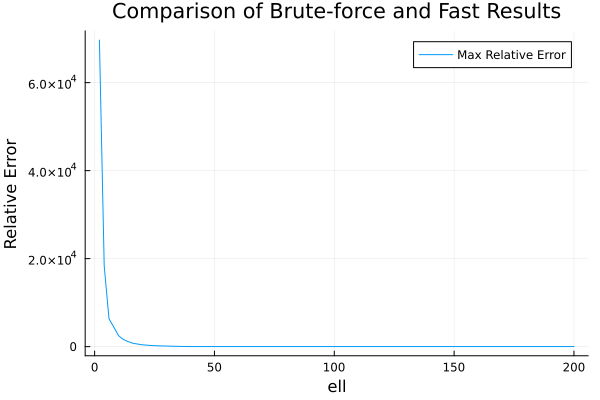

In [87]:
#now i want to plot this difference
plot(ells, [cmp.relerr_dict[ℓ] for ℓ in ells], label = "Max Relative Error", xlabel = "ell", ylabel = "Relative Error", title = "Comparison of Brute-force and Fast Results")